In [1]:
"""Reproducibility:

This flag is necessary for ensuring reproducibility on Colab.
Removing it significantly boosts performance (5-10x) but compromises
result consistency due to inherent GPU non-determinism.
"""

import os

os.environ['XLA_FLAGS'] = ' --xla_gpu_deterministic_ops=true'

In [21]:
# @title Imports and Notebook Utilities
from collections import namedtuple
from datetime import datetime
from functools import partial
import io
import itertools
from base64 import b64decode
from typing import List, Optional, Sequence, Tuple

from einops import rearrange
import flax.linen as nn
import flax.linen as nn
from IPython.display import HTML, Image, clear_output
import jax
print(jax.__version__)
from jax import grad
from jax.lax import conv_general_dilated_patches
import jax.numpy as jnp
import jax.random as random
from jax.tree_util import tree_leaves, tree_map
import math
from matplotlib import colors
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib.style as style
from matplotlib.ticker import MaxNLocator
import numpy as np
import optax
import PIL
import PIL.Image, PIL.ImageDraw, PIL.ImageFont, PIL.ImageOps
import requests


import jax
import jax.numpy as jnp
from einops import rearrange
from typing import Callable

from collections import namedtuple
import jax
import jax.numpy as jnp
import optax
from einops import rearrange
from typing import Literal

os.environ['FFMPEG_BINARY'] = 'ffmpeg'

0.9.0.1


In [22]:
# @title Hyperparameters

# Index of the pass-through gate used for network initialization.
PASS_THROUGH_GATE = 3
DEFAULT_PASS_VALUE = 10.0

# Number of possible gates with 2 inputs and 1 output.
NUMBER_OF_GATES = 16

"""
Fire rate for asynchronicity.

60% of cells will perform the update,
40% will have the update masked.
"""
FIRE_RATE = 0.6

TARGET_EMOJI = "🦎"
TARGET_SIZE_EMOJI = 20
TARGET_SIZE_G = 16
TARGET_SIZE_ASYNC = 14
TARGET_SIZE = 16

In [23]:
# @title base64 lizard image
'''
Importing the Lizard image in base64 format.
'''
lizard_byte = b64decode("iVBORw0KGgoAAAANSUhEUgAAACAAAAAgCAYAAABzenr0AAAAAXNSR0IArs4c6QAAAERlWElmTU0AKgAAAAgAAYdpAAQAAAABAAAAGgAAAAAAA6ABAAMAAAABAAEAAKACAAQAAAABAAAAIKADAAQAAAABAAAAIAAAAACshmLzAAAFrElEQVRYCcVXzW9bRRD/7b73bOfbaUnlfualtETQiDoUiYoPyZYoibi0pqQS6gH7ABKnNleEmlZIPcAh4i9wOABSU9RcUJMiSBASKiCIQQRSVClu2qahH66DE3++t8usU6e29RJwaGGl9e7OzM7Mm/nt7Br4nxtby752pjcsmRyUEhPSyEUQmkiuJb8enr7qpjMH/GQ8qviM4RCz3UkBRFaVXyeDr7aPMT5YwZMI8+HekxW0B7BwTIE+3BsQkOPl+vnsEmS9Dtvr6cBro/Fy3r+ZO6aAQh3Qx+agTS8g/8buomHPOzGIx1uQfbtroJQKPtxTjJIE/FLPhdaDEccUSCn36j8moP2QALudK36g9cImWE9tAAHSLBIIIzSGqR+nMAa45VbzmptjBAh08Rx9OUtbkDsa4OYM8s3HYJH1UuOMT9K8/FS0l3i1jI4RYJL9JB9xQ5DxFp2h08PxRL2GRu0+ZBiTITIURzqtojIi+sb6azFcknV0wDayIyRQ/Do3heP0z0n0WgLdDTo895ywX70wIqan+sWVONj8fHkkSrr/0eiYAgUmdvaliJTsXFZIXKZodNZpkORAypaBKQJfbn7uKyQXBgAJkUyYTtYIpMeJTjKqlsiIcrpa7n5Mqzm0VpVQ4zK6v8nAwQ0udF3PYNKW+IhSMp2xYSWTkLdvx5HNhnDyeqxcBRlXGFHNpO4F4UoUWLD6CDumQO1STYHRFixyNWdjlvqW2TSeJgeCLQb2UE1we1vBH91l8q6uYzgX8C7vWv4lXMRpZlJX9CR1+iK7QkaRnCNAR4xQHiW+X1iso86F8eeadPPgRhfadI62Syl8R6C84OL4NW3jDuGDMhXji0v91rXZQUKln7yPMZ/PZN5WZTQm9FzQqU5oyouKRl/CpBElz/YrumTiQwGeWxIy4KHj2O7m6Li8iDaDo3lzHU58eROZVhdmPdyX5TwsFxd9sCy11ccY87DmFpX/t+ThL2KKWN0cQUjGV0JFkXhd/Dblv7VzJ77RGtBAp4Dt34jdUwvoTFmoI+MvUkryTTq+TXHMbNkC+8qVJFyekPTtiMu+0Xi10fK1YwrYmZ5zlP8AJSgp7yRM+cc84PFAazfRUW/g+WYdp0fmMB1oQ7rZQFMih0VKzc25DN7bXo9LC5mYODreXW5otbkjCNXdT7nv5pJFkEot781mh2yG7pmsnTx/t4Dwyz5caHOD38qi8U4ekhzZ5dHwLDm3rdHjVxfaakbL6Y4RKBfAu9sP0VH34sTVoSL9k16T6TJqUIS2Egj3Nep4ho7pNpobeYH8zSw+dmv4+s/CxMIro8EKXQ6Lv3fAYRNOml40uMdZq9ffuKG1WCEPeA346UTsOz+H9w9uw2eJPH63RAdCa2PAEYRONitoXISRSftlJo1UIoGLW7dSkBrRSMd06agJH9WMzRSRG5YIUAKHKvZWLRwxUCVTsSzmVvAhaFpcMVjbprhweYKTqULsOzoVWqqA9msZtNBp8UDurdjssKgpAqWXEt/TuayqUAAMw7QhBxYLLHQxVZh5ko5lC3VNXd2M+x1sVpBqioClZ2OqppOGZFGLYRSvYg3slKrxN/Ji6PuCwBRd4YRH4omVelJhtWxRMwjpkrmr6gMl3SQ9SXoHtK7ooxLeWW9MbqYqmaHa/AuBcunw6Jo21mSuKK6asOGecdqowusVUnTjyOexkkjdp70zzRoz6c5Cku4Iq2+MgRxj4ANKhi7vU+XyNWGgZERaLEL6oeswRZlxxc8J+cEtIQdLssu4oaoKaRJNOUIvbqxEbV0RIEWrN7rM6IE6QwLF/KvnmjwyFlIbKH3Kb3CwoNU3OqHmD94BUnrvL11UGVBNOaFGul8OqVFd8aWHyUNxQBnhZ3uilPCwmpc3CsGE7BsLlmgPzQFlQOXflvIYxbmYDvXCElqu3+lhUnLoPx//Aq5HH06LSa+UAAAAAElFTkSuQmCC")

In [24]:
# @title Utils and Plotting


def zoom(img, scale=4):
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img


def load_byte(byte, max_size=TARGET_SIZE):
  img = PIL.Image.open(io.BytesIO(byte))
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img) / 255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

def visualize(frames, namefile, size, negate=1):
  # Create and save animation
  fig, ax = plt.subplots(figsize=(size, size))
  ax.set_xticks([])
  ax.set_yticks([])

  def animate(frame):
    ax.clear()
    ax.set_xticks([])
    ax.set_yticks([])

    if negate:
      frame = 1 - frame

    return [ax.imshow(frame, cmap='binary')]

  anim = animation.FuncAnimation(fig, animate, frames=frames, interval=200, blit=True)

  # Save the gif
  writer = animation.PillowWriter(fps=2)
  anim.save(namefile, writer=writer)
  plt.close()


def plot_show(img, negate=1):
  if negate:
    img = 1 - img
  fig, ax = plt.subplots(1, 1, figsize=(5, 5))
  ax.imshow(img, cmap='binary')
  ax.axis('off')
  plt.tight_layout()
  plt.show()


# Plot the histogram related to the statistics of the gates.
def plot_hist_gates(
    net, save_path=None, title='Distribution of Gates (Sorted)'
):
  gate_types = [
      'FALSE',
      'AND',
      'A AND (NOT B)',
      'A',
      '(NOT A) AND B',
      'B',
      'XOR',
      'OR',
      'NOR',
      'XNOR',
      'NOT B',
      'A OR (NOT B)',
      'NOT A',
      '(NOT A) OR B',
      'NAND',
      'TRUE',
  ]

  gate_counts = np.bincount(net, minlength=len(gate_types))
  sorted_indices = np.argsort(gate_counts)
  sorted_counts = gate_counts[sorted_indices]
  sorted_gate_types = [gate_types[i] for i in sorted_indices]
  fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

  ax.barh(
      sorted_gate_types,
      sorted_counts,
      color='#2E86C1',
      alpha=0.7,
      edgecolor='white',
      linewidth=1,
  )

  ax.set_xlabel('#Gates', fontsize=12, fontweight='bold')
  ax.set_ylabel('Type of gate', fontsize=12, fontweight='bold')
  ax.set_title(
      'Distribution of Gates (Sorted)', fontsize=14, fontweight='bold', pad=20
  )

  plt.style.use('seaborn-v0_8-darkgrid')
  ax.grid(True, linestyle='--', alpha=0.7, axis='x')
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax.set_facecolor('#f8f9fa')
  fig.set_facecolor('white')
  plt.tight_layout()

  if save_path:
    with open(save_path, 'wb') as f:
      plt.savefig(f, format='svg')
  plt.show()


# Plot the training loss functions.
def plot_training_progress(
    loss_train, loss_test, compute_every, save_path=None
):
  plt.style.use('seaborn-v0_8-darkgrid')

  fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

  ax.grid(True, color='gray', linestyle='-', linewidth=0.8, alpha=0.3)

  ax.plot(
      loss_train,
      color='#2E86C1',
      linewidth=2,
      label='Soft Gates Loss',
      alpha=0.9,
  )

  ax.plot(
      np.arange(0, len(loss_train), compute_every),
      loss_test,
      color='#E74C3C',
      linestyle='--',
      linewidth=2,
      label='Hard Gates Loss',
      alpha=0.9,
  )

  ax.grid(True, linestyle='--', alpha=0.7)

  ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
  ax.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
  ax.set_title(
      'Training Progress - Soft vs Hard Gates',
      fontsize=14,
      fontweight='bold',
      pad=20,
  )

  ax.legend(
      frameon=True, fancybox=True, shadow=True, fontsize=10, loc='upper right'
  )

  for spine in ax.spines.values():
    spine.set_linewidth(1.5)

  ax.set_facecolor('#f8f9fa')
  fig.set_facecolor('white')

  plt.tight_layout()

  if save_path:
    with open(save_path, 'wb') as f:
      plt.savefig(f, format='svg')

  plt.show()

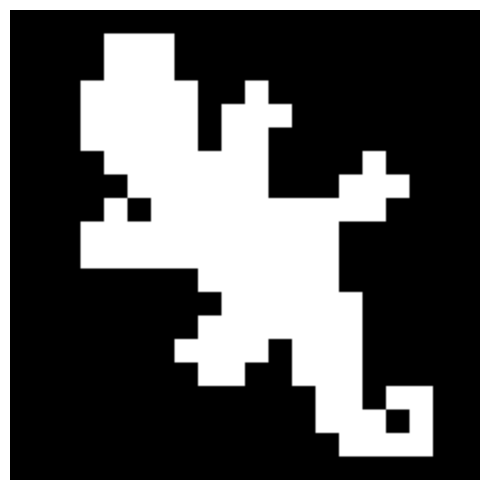

In [25]:
# @title Learning to Grow the lizard
jax.clear_caches()
# Outline of the lizard, creating a mask with 1 and 0 to use as target image
# target_img = load_byte(lizard_byte, TARGET_SIZE_EMOJI) > 0.26
target_img = load_byte(lizard_byte, TARGET_SIZE_EMOJI) > 0.26

target_img = (
    target_img[..., 2] | target_img[..., 1] | target_img[..., 0]
).astype(jnp.float32)


plot_show(zoom(target_img[..., None], 8))

In [27]:
def next_power_of_2(n: int) -> int:
    if n < 1:
        raise ValueError("n must be >= 1")
    return 1 << (n - 1).bit_length()


def pad_1d_to_next_power_of_2(x: jnp.ndarray, pad_value: float = 0.0) -> jnp.ndarray:
    """
    Pad a 1D array on the right to the next power of 2.
    """
    n = x.shape[0]
    target = next_power_of_2(n)
    pad_width = [(0, target - n)]
    return jnp.pad(x, pad_width, constant_values=pad_value)


def pad_2d_to_next_power_of_2(x: jnp.ndarray, pad_value: float = 0.0) -> jnp.ndarray:
    """
    Pad a 2D array on bottom/right so each dimension reaches the next power of 2.
    """
    h, w = x.shape
    target_h = next_power_of_2(h)
    target_w = next_power_of_2(w)

    pad_width = [
        (0, target_h - h),
        (0, target_w - w),
    ]
    return jnp.pad(x, pad_width, constant_values=pad_value)


def pad_image_channels_to_next_power_of_2(x: jnp.ndarray, pad_value: float = 0.0) -> jnp.ndarray:
    """
    Pad an image of shape (H, W, C) on bottom/right only.
    Channels are left unchanged.
    """
    h, w, c = x.shape
    target_h = next_power_of_2(h)
    target_w = next_power_of_2(w)

    pad_width = [
        (0, target_h - h),
        (0, target_w - w),
        (0, 0),
    ]
    return jnp.pad(x, pad_width, constant_values=pad_value)

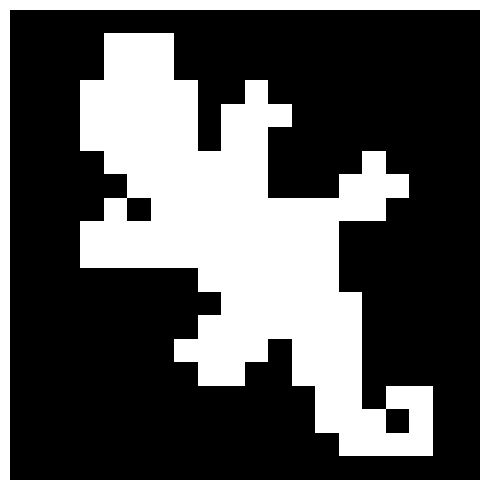

(20, 20)
(32, 32)


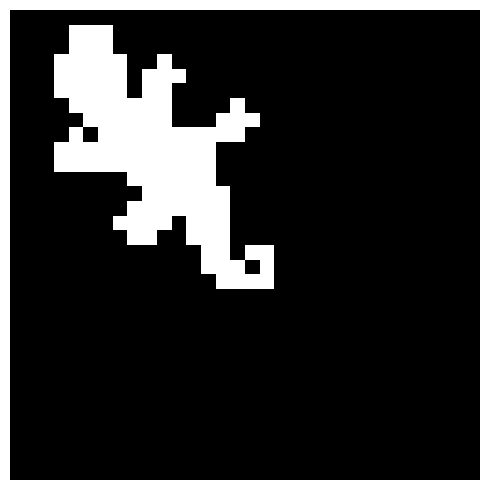

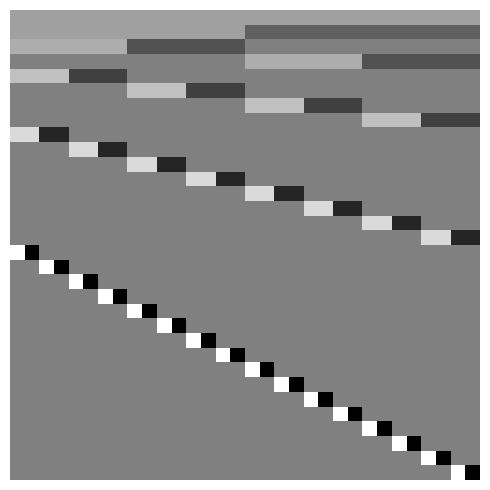

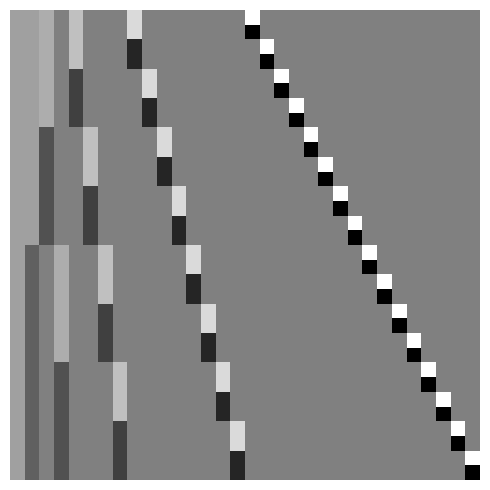

(32, 32)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
2.9802322e-08


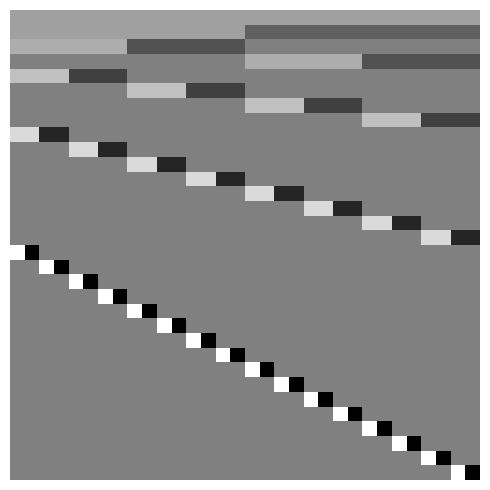

In [43]:
def haar_matrix(n: int, normalized: bool = True) -> jnp.ndarray:
    """
    Construct the n x n Haar wavelet transform matrix.
    Requires n to be a power of 2.

    If normalized=True, rows are orthonormal.
    """
    if n < 1 or (n & (n - 1)) != 0:
        raise ValueError("n must be a positive power of 2")

    H = jnp.array([[1.0]])

    while H.shape[0] < n:
        m = H.shape[0]
        top = jnp.kron(H, jnp.array([[1.0, 1.0]]))
        bottom = jnp.kron(jnp.eye(m), jnp.array([[1.0, -1.0]]))
        H = jnp.vstack([top, bottom])

    if normalized:
        # Normalize each row to unit norm
        row_norms = jnp.linalg.norm(H, axis=1, keepdims=True)
        H = H / row_norms

    return H


def random_haar_orthogonal(key: jax.Array, n: int) -> jnp.ndarray:
    """
    Generate an n x n Haar-distributed random orthogonal matrix.
    """
    A = jax.random.normal(key, (n, n))
    Q, R = jnp.linalg.qr(A)

    # Fix signs so distribution is truly Haar
    d = jnp.sign(jnp.diag(R))
    d = jnp.where(d == 0, 1.0, d)
    Q = Q * d[None, :]
    return Q



plot_show(target_img)
x_pad = pad_2d_to_next_power_of_2(target_img)
print(x.shape)      # (20, 20)
print(x_pad.shape)  # (32, 32)
plot_show(x_pad)
haar = haar_matrix(32, True)
haar2 = haar.T
plot_show(haar)
plot_show(haar2)
# good_haar = haar.T @ haar
haar = haar_matrix(32)
check = haar.T @ haar

print(check.shape)
print(jnp.diag(check))
print(jnp.max(jnp.abs(check - jnp.eye(32))))
plot_show(haar)
# # Example
# H8 = haar_matrix(20, True)
# print(H8)
# print("H^T H =\n", H8.T @ H8)

# x = jnp.arange(20)
# # y = H8 @ x
# print(x)


# Example
# key = jax.random.PRNGKey(0)
# Q = random_haar_orthogonal(key, 4)
# print(Q)
# print("Q^T Q =\n", Q.T @ Q)

In [44]:
haar = haar_matrix(32)   # shape (32, 32)

# one 2D basis image
basis_3_5 = jnp.outer(haar[3], haar[5])   # shape (32, 32)

# all 1024 basis images
basis_images = jnp.stack(
    [jnp.outer(haar[i], haar[j]) for i in range(32) for j in range(32)],
    axis=0
)  # shape (1024, 32, 32)

print(basis_images.shape)
# (1024, 32, 32)

(1024, 32, 32)


In [53]:
def visualize_basis_animation(frames, namefile, size=5, negate=1, interval=150):
    """
    frames: array of shape (N, H, W)
    Saves an animated GIF.
    """
    frames = jnp.asarray(frames)

    fig, ax = plt.subplots(figsize=(size, size))
    ax.set_xticks([])
    ax.set_yticks([])

    first = frames[0]
    if negate:
        first = 1 - first

    im = ax.imshow(first, cmap="binary", animated=True)
    ax.axis("off")

    def animate(i):
        frame = frames[i]
        if negate:
            frame = 1 - frame
        im.set_array(frame)
        return [im]

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=frames.shape[0],
        interval=interval,
        blit=True,
    )

    writer = animation.PillowWriter(fps=max(1, int(1000 / interval)))
    anim.save(namefile, writer=writer)
    plt.close(fig)
    
visualize_basis_animation(basis_images[:64], "haar_basis_64.gif", size=5, negate=0, interval=200)

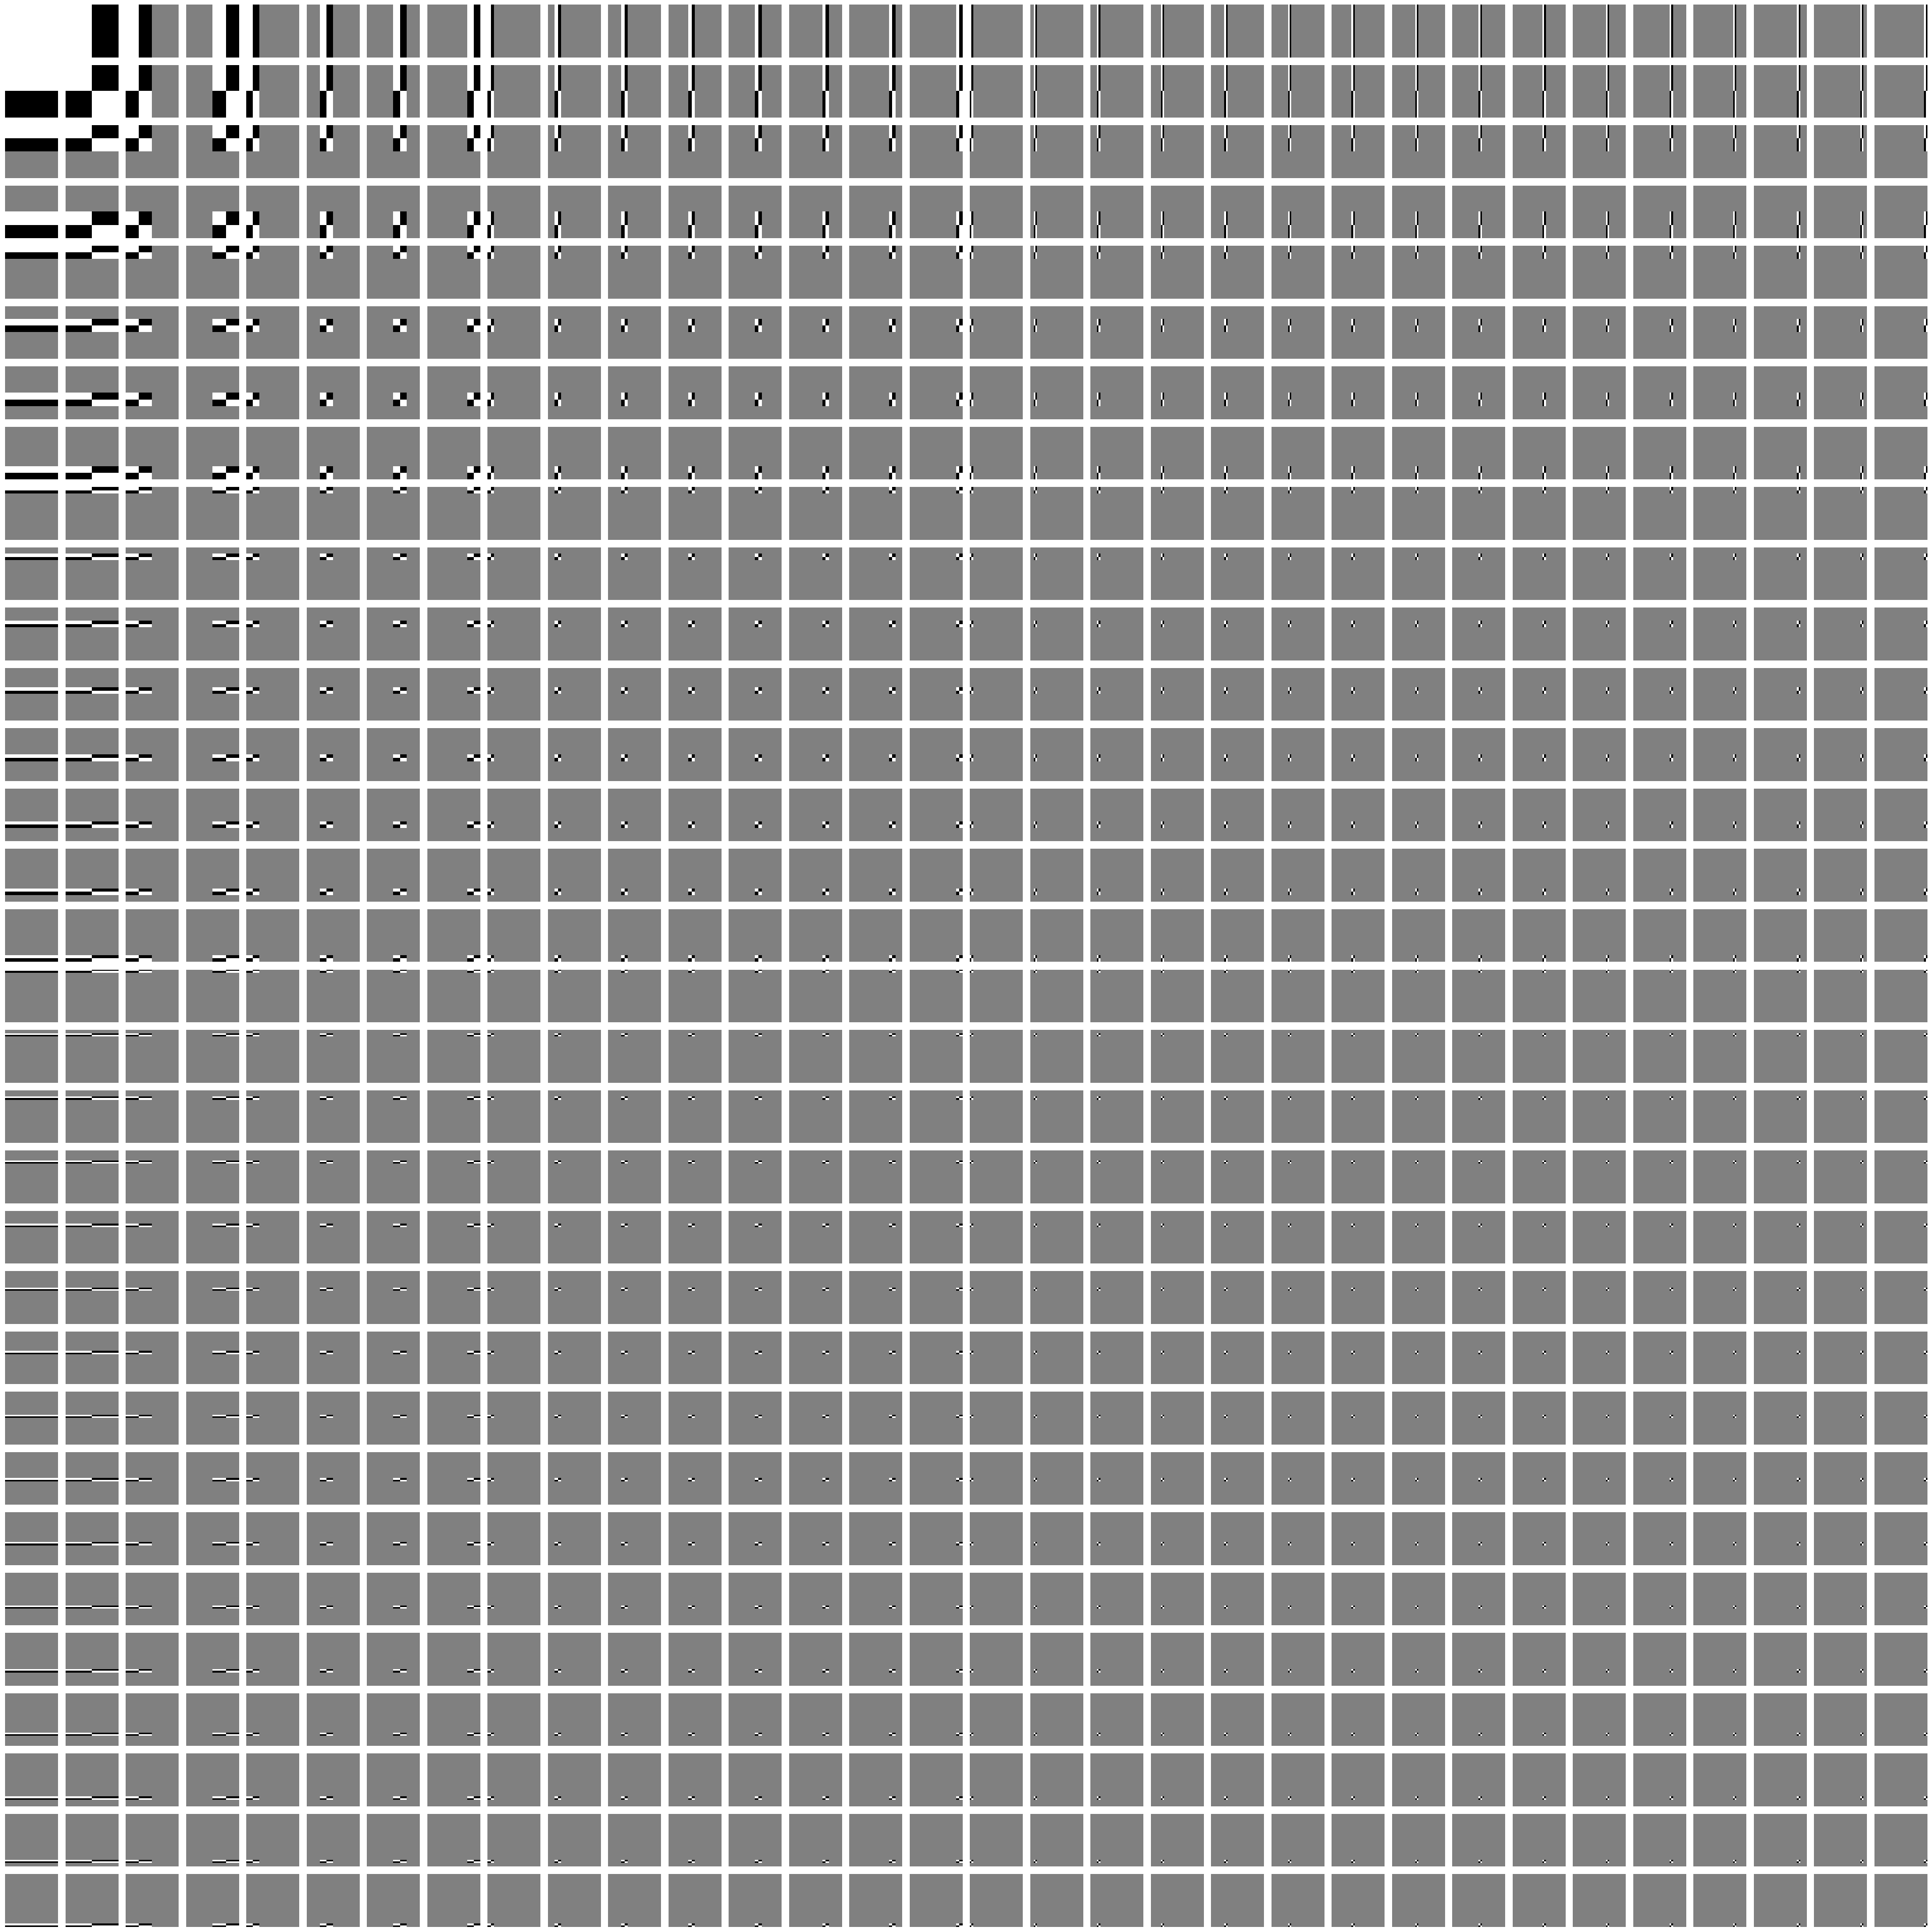

In [56]:
def plot_basis_grid(images, cols=None, figsize_per_cell=1.2):
    images = jnp.asarray(images)
    n = images.shape[0]

    if cols is None:
        cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(cols * figsize_per_cell, rows * figsize_per_cell)
    )

    axes = np.atleast_1d(axes).ravel()

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            img = images[i]
            lim = float(jnp.max(jnp.abs(img)))
            if lim == 0:
                lim = 1.0
            ax.imshow(img, cmap="gray", vmin=-lim, vmax=lim)

    plt.tight_layout()
    plt.show()
    
plot_basis_grid(basis_images)

(32, 32)
1.7881393e-07


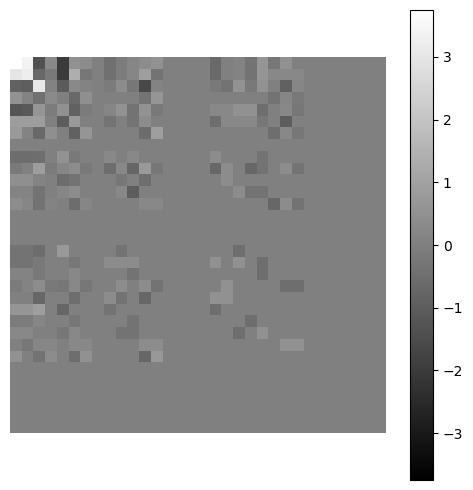

[[ 3.7499995   3.3749995  -1.3258252  ...  0.          0.
   0.        ]
 [ 2.9999998   3.2499998  -0.7071068  ...  0.          0.
   0.        ]
 [-0.8838834  -0.97227174  3.0625     ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
3.7499995
-1.9999999


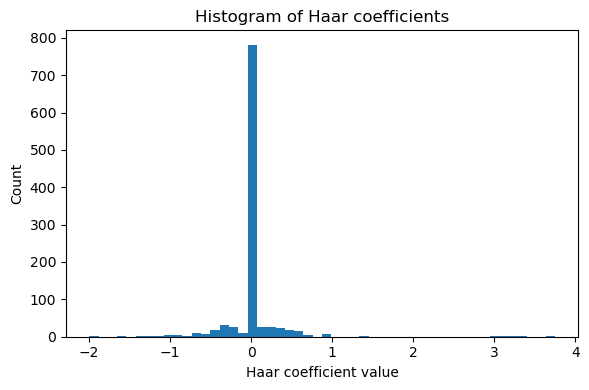

In [90]:
def haar_transform_2d(img: jnp.ndarray, H: jnp.ndarray) -> jnp.ndarray:
    """
    img: shape (32, 32)
    H:   shape (32, 32) Haar matrix
    returns: shape (32, 32) Haar coefficients
    """
    return H @ img @ H.T


def inverse_haar_transform_2d(coeffs: jnp.ndarray, H: jnp.ndarray) -> jnp.ndarray:
    """
    Since H is orthonormal, H^{-1} = H^T
    """
    return H.T @ coeffs @ H

haar = haar_matrix(32)
img = x_pad   # shape (32, 32)

coeffs = haar_transform_2d(img, haar)
recon = inverse_haar_transform_2d(coeffs, haar)

print(coeffs.shape)   # (32, 32)
print(jnp.max(jnp.abs(img - recon)))  # should be tiny
def plot_single(img):
    img = jnp.asarray(img)
    lim = float(jnp.max(jnp.abs(img)))
    if lim == 0:
        lim = 1.0

    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray", vmin=-lim, vmax=lim)
    plt.colorbar()
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
plot_single(coeffs)
print(coeffs)
print(jnp.max(coeffs))
print(jnp.min(coeffs))

coeffs_flat = np.array(coeffs).ravel()

plt.figure(figsize=(6, 4))
plt.hist(coeffs_flat, bins=50)
plt.xlabel("Haar coefficient value")
plt.ylabel("Count")
plt.title("Histogram of Haar coefficients")
plt.tight_layout()
plt.show()

In [74]:
coeffs_norm_linalg = coeffs / jnp.linalg.norm(coeffs)
coeffs_norm_max = coeffs / jnp.max(jnp.abs(coeffs))
coeffs_norm_mean = (coeffs - jnp.mean(coeffs)) / (jnp.std(coeffs) + 1e-8)


120.0
119.999985


In [76]:
def see_histogram(coeffs):
    coeffs_flat = np.array(coeffs).ravel()
    plt.figure(figsize=(6, 4))
    plt.hist(coeffs_flat, bins=50)
    plt.xlabel("Haar coefficient value")
    plt.ylabel("Count")
    plt.title("Histogram of Haar coefficients")
    plt.tight_layout()
    plt.show()

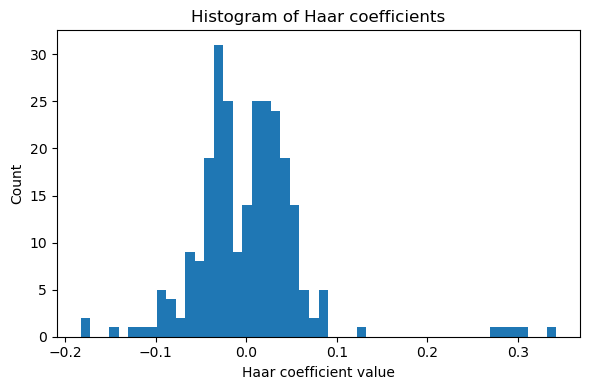

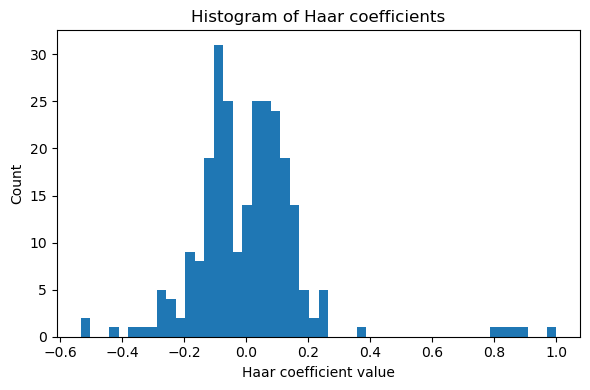

In [89]:
see_histogram(coeffs_norm_linalg[coeffs_norm_linalg!=0])
see_histogram(coeffs_norm_max[coeffs_norm_max!=0])

0.0
1.0


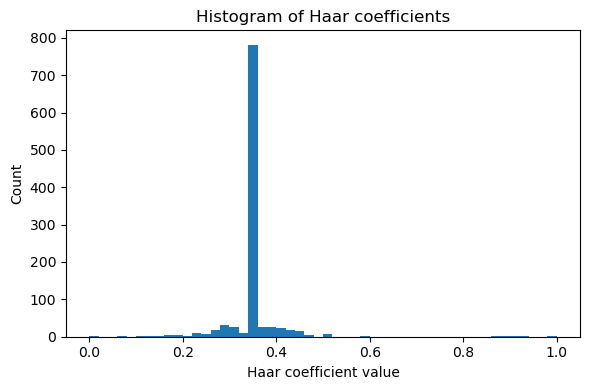

[[1.         0.9347826  0.11724778 ... 0.3478261  0.3478261  0.3478261 ]
 [0.86956525 0.9130435  0.22485098 ... 0.3478261  0.3478261  0.3478261 ]
 [0.19410723 0.17873533 0.8804349  ... 0.3478261  0.3478261  0.3478261 ]
 ...
 [0.3478261  0.3478261  0.3478261  ... 0.3478261  0.3478261  0.3478261 ]
 [0.3478261  0.3478261  0.3478261  ... 0.3478261  0.3478261  0.3478261 ]
 [0.3478261  0.3478261  0.3478261  ... 0.3478261  0.3478261  0.3478261 ]]


In [93]:
def minmax_01(x: jnp.ndarray, eps: float = 1e-8) -> jnp.ndarray:
    x_min = jnp.min(x)
    x_max = jnp.max(x)
    return (x - x_min) / (x_max - x_min + eps)

coeffs_01 = minmax_01(coeffs)

print(jnp.min(coeffs_01))  # ~0.0
print(jnp.max(coeffs_01))  # ~1.0
see_histogram(coeffs_01)
print(coeffs_01)

In [94]:
unique_vals = jnp.unique(coeffs_01)
print(unique_vals)

[0.         0.06521738 0.11724778 0.13043478 0.1521739  0.16336346
 0.17391305 0.17873533 0.19410722 0.19410723 0.19565219 0.21739131
 0.22485098 0.22485101 0.23913044 0.24022287 0.2555948  0.26086956
 0.2608696  0.27096665 0.27173913 0.28260872 0.28633854 0.30434784
 0.31708232 0.31708235 0.32608697 0.3324542  0.3478261  0.34782612
 0.3586957  0.36319798 0.36956522 0.36956525 0.37856984 0.3785699
 0.39130434 0.39130437 0.39394176 0.40217397 0.40931362 0.40931365
 0.41304347 0.41304353 0.42468557 0.43478262 0.43478265 0.44005743
 0.4554293  0.45652175 0.45652178 0.4708012  0.47826087 0.47826093
 0.5        0.50000006 0.50154495 0.501545   0.58695656 0.86956525
 0.8804349  0.9130435  0.9347826  1.        ]


(64,)


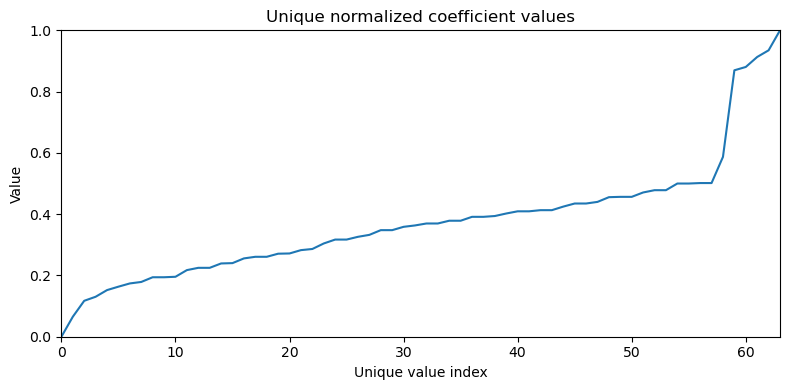

In [96]:
unique_vals = np.unique(np.array(coeffs_01).ravel())

plt.figure(figsize=(8, 4))
plt.plot(unique_vals)
plt.ylim(0, 1)
plt.xlim(0, len(unique_vals) - 1)
plt.xlabel("Unique value index")
plt.ylabel("Value")
plt.title("Unique normalized coefficient values")
plt.tight_layout()
plt.show()

In [97]:
vals = np.sort(np.unique(np.round(np.array(coeffs_01).ravel(), 6)))
gaps = np.diff(vals)

print(vals)
print(gaps)
print("max gap:", gaps.max())
print("min gap:", gaps.min())
print("median gap:", np.median(gaps))

[0.       0.065217 0.117248 0.130435 0.152174 0.163363 0.173913 0.178735
 0.194107 0.195652 0.217391 0.224851 0.23913  0.240223 0.255595 0.26087
 0.270967 0.271739 0.282609 0.286339 0.304348 0.317082 0.326087 0.332454
 0.347826 0.358696 0.363198 0.369565 0.37857  0.391304 0.393942 0.402174
 0.409314 0.413043 0.413044 0.424686 0.434783 0.440057 0.455429 0.456522
 0.470801 0.478261 0.5      0.501545 0.586957 0.869565 0.880435 0.913044
 0.934783 1.      ]
[6.5217003e-02 5.2030995e-02 1.3187006e-02 2.1738991e-02 1.1188999e-02
 1.0550007e-02 4.8220009e-03 1.5371993e-02 1.5449971e-03 2.1739006e-02
 7.4599981e-03 1.4279008e-02 1.0930002e-03 1.5371993e-02 5.2750111e-03
 1.0096997e-02 7.7199936e-04 1.0869980e-02 3.7300289e-03 1.8008977e-02
 1.2733996e-02 9.0050101e-03 6.3669980e-03 1.5372008e-02 1.0870010e-02
 4.5019984e-03 6.3669980e-03 9.0049803e-03 1.2733996e-02 2.6380122e-03
 8.2319975e-03 7.1400106e-03 3.7289858e-03 1.0132790e-06 1.1642009e-02
 1.0096997e-02 5.2739978e-03 1.5371978e-02 1.0

In [98]:
abs_norm = jnp.abs(coeffs) / (jnp.max(jnp.abs(coeffs)) + 1e-8)
energy = coeffs**2
energy_frac = energy / (jnp.sum(energy) + 1e-8)

[[0.99999994 0.8999999  0.3535534  ... 0.         0.         0.        ]
 [0.79999995 0.8666667  0.18856183 ... 0.         0.         0.        ]
 [0.23570226 0.2592725  0.8166667  ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
[[0.11718748 0.09492186 0.01464844 ... 0.         0.         0.        ]
 [0.075      0.08802082 0.00416667 ... 0.         0.         0.        ]
 [0.00651042 0.0078776  0.07815756 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


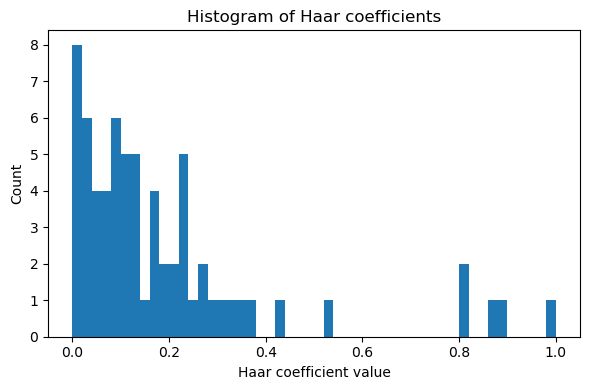

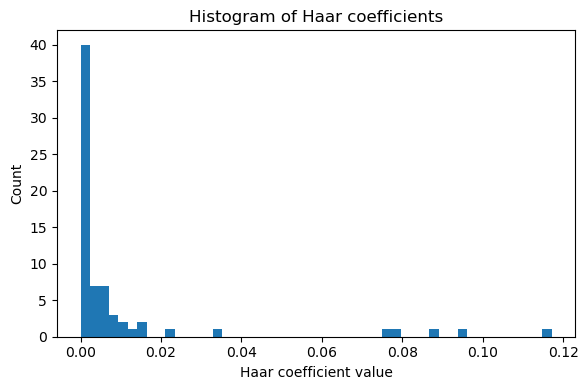

(67,)
(69,)


In [106]:
print(abs_norm)
print(energy_frac)

# see_histogram(np.unique(abs_norm))
# see_histogram(np.unique(energy_frac))

see_histogram(np.unique(abs_norm))
see_histogram(np.unique(energy_frac))

print(np.unique(abs_norm).shape)
print(np.unique(energy_frac).shape)